In [1]:
#1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [ ]:
#2 Load and prepare daily Brent price data
brent_price = pd.read_csv('brent-crude-oil.csv')
#3 Change of data format
brent_price['date'] = pd.to_datetime(brent_price['date'])
print(brent_price)

           date  brent_price_usd
0    1987-05-20            18.63
1    1987-05-21            18.45
2    1987-05-22            18.55
3    1987-05-25            18.60
4    1987-05-26            18.63
...         ...              ...
9937 2026-07-21            93.85
9938 2026-07-22            94.12
9939 2026-07-23           105.32
9940 2026-07-24           100.31
9941 2026-07-27            91.82

[9942 rows x 2 columns]


In [3]:
#4 Check Brent data sructure and data types
brent_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 9942 entries, 0 to 9941
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             9942 non-null   datetime64[us]
 1   brent_price_usd  9942 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 155.5 KB


In [ ]:
#5 Load and prepare Saudi Arabia oil production data
Saudi_prod = pd.read_csv('SAUNGDPMOMBD.csv')

pd.set_option('display.float_format', '{:,.0f}'.format)
Saudi_prod["observation_date"] = pd.to_datetime(Saudi_prod["observation_date"])
print(Saudi_prod)

   observation_date  SAUNGDPMOMBD
0        2000-01-01     8,090,000
1        2001-01-01     7,890,000
2        2002-01-01     7,090,000
3        2003-01-01     8,410,000
4        2004-01-01     8,900,000
5        2005-01-01     9,350,000
6        2006-01-01     9,210,000
7        2007-01-01     8,820,000
8        2008-01-01     9,200,000
9        2009-01-01     8,180,000
10       2010-01-01     8,170,000
11       2011-01-01     9,310,000
12       2012-01-01     9,760,000
13       2013-01-01     9,630,000
14       2014-01-01     9,710,000
15       2015-01-01    10,190,000
16       2016-01-01    10,460,000
17       2017-01-01     9,950,000
18       2018-01-01    10,310,000
19       2019-01-01     9,810,000
20       2020-01-01     9,217,085
21       2021-01-01     9,125,000
22       2022-01-01    10,588,500
23       2023-01-01     9,612,583
24       2024-01-01     8,988,481
25       2025-01-01     9,595,579


In [5]:
#6 Check Crude Oil Production for Saudi Arabia data sructure
Saudi_prod.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  26 non-null     datetime64[us]
 1   SAUNGDPMOMBD      26 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 548.0 bytes


In [ ]:
#7 Load and prepare UAE oil production data
uae_prod = pd.read_csv('ARENGDPMOMBD.csv')
uae_prod["observation_date"] = pd.to_datetime(uae_prod["observation_date"])
print(uae_prod)

   observation_date  ARENGDPMOMBD
0        2000-01-01     2,190,000
1        2001-01-01     2,120,000
2        2002-01-01     1,930,000
3        2003-01-01     2,260,000
4        2004-01-01     2,330,000
5        2005-01-01     2,380,000
6        2006-01-01     2,600,000
7        2007-01-01     2,530,000
8        2008-01-01     2,618,000
9        2009-01-01     2,242,000
10       2010-01-01     2,324,000
11       2011-01-01     2,564,000
12       2012-01-01     2,653,000
13       2013-01-01     2,797,000
14       2014-01-01     2,788,274
15       2015-01-01     2,875,000
16       2016-01-01     3,034,829
17       2017-01-01     2,936,990
18       2018-01-01     3,005,000
19       2019-01-01     3,060,765
20       2020-01-01     2,771,596
21       2021-01-01     2,632,083
22       2022-01-01     3,065,250
23       2023-01-01     2,951,000
24       2024-01-01     2,925,833
25       2025-01-01     3,212,917


In [7]:
#8 Check Crude Oil Production for UAE data sructure
uae_prod.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  26 non-null     datetime64[us]
 1   ARENGDPMOMBD      26 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 548.0 bytes


In [ ]:
#9 Load and prepare global oil demand data
World_demand = pd.read_csv('world_demand_crude_oil.csv')
World_demand = World_demand.rename(columns={
    'Unnamed: 0':'year'})
World_demand["year"] = pd.to_datetime(World_demand["year"].astype(str).str.replace('*', '', regex=False), format='%Y')
World_demand = World_demand.rename(columns={'Demand in million barrels per day' : 'World_Demand'})
print(World_demand)

         year  World_Demand
0  2005-01-01            84
1  2006-01-01            85
2  2007-01-01            86
3  2008-01-01            86
4  2009-01-01            85
5  2010-01-01            85
6  2011-01-01            87
7  2012-01-01            89
8  2013-01-01            91
9  2014-01-01            92
10 2015-01-01            94
11 2016-01-01            96
12 2017-01-01            98
13 2018-01-01            99
14 2019-01-01           100
15 2020-01-01            91
16 2021-01-01            97
17 2022-01-01           100
18 2023-01-01           102
19 2024-01-01           104
20 2025-01-01           105
21 2026-01-01           106


In [9]:
#10 Check world demand oil data structure
World_demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          22 non-null     datetime64[us]
 1   World_Demand  22 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 484.0 bytes


In [ ]:
#11 Load and prepare Nominal US dollar index data
DTWEXBGS = pd.read_csv('DTWEXBGS(jan2006).csv')
DTWEXBGS["observation_date"] = pd.to_datetime(DTWEXBGS["observation_date"])
DTWEXBGS = DTWEXBGS.dropna(subset=['DTWEXBGS'])
print(DTWEXBGS)

     observation_date  DTWEXBGS
0          2006-01-02       101
1          2006-01-03       101
2          2006-01-04       100
3          2006-01-05       100
4          2006-01-06       100
...               ...       ...
5370       2026-08-03       121
5371       2026-08-04       120
5372       2026-08-05       119
5373       2026-08-06       120
5374       2026-08-07       119

[5164 rows x 2 columns]


In [11]:
#12 Check Nominal US dollar index data data structure
DTWEXBGS.info()

<class 'pandas.DataFrame'>
Index: 5164 entries, 0 to 5374
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  5164 non-null   datetime64[us]
 1   DTWEXBGS          5164 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 121.0 KB


In [12]:
#13 Merge datasets into a single analytical table
cop = pd.merge(Saudi_prod, uae_prod, on='observation_date', how='inner')
cop = pd.merge(cop, World_demand,
                left_on=['observation_date'], right_on=['year'],
                how='inner')
cop = cop.drop(columns='year')
#14 Convert global oil demand from million barrels/day to barrels/day
cop['World_Demand'] = cop['World_Demand'] * 1_000_000
#15 Add daily Brent prices to the analytical table
cop = pd.merge(cop, brent_price, 
            left_on=['observation_date'], 
            right_on=['date'],
            how='left')
cop = cop.drop(columns='date')
#16 Calculate annual average Brent price
brent_price['year'] = brent_price['date'].dt.year
brent_year = (
    brent_price.groupby('year', as_index=False)['brent_price_usd']
      .mean()
)
cop['year'] = cop['observation_date'].dt.year
cop = pd.merge(cop, brent_year, on='year', how='left')
cop = cop.drop(columns='year')
cop = cop.drop(columns='brent_price_usd_x')
cop = cop.rename(columns={'brent_price_usd_y' : 'brent_price_mean'})
#17 Calculate annual average Nominal US dollar index
DTWEXBGS['year'] = DTWEXBGS['observation_date'].dt.year
DTWEXBGS_year = (DTWEXBGS.groupby('year')['DTWEXBGS']
       .mean()
       .reset_index()
)
#18 Add annual average US dollar index to the analytical table
cop['year'] = cop['observation_date'].dt.year
cop = pd.merge(
    cop,
    DTWEXBGS_year,
    on='year',
    how='left'
)
cop = cop.drop(columns='year')
cop = cop.rename(columns={'DTWEXBGS' : 'TWEXBGSANL'})
#19 The annual DXY value for 2005 was manually assigned as 98 because the available DXY dataset starts in 2006
cop.loc[cop['observation_date'].dt.year == 2005, 'TWEXBGSANL'] = 98
print(cop)



   observation_date  SAUNGDPMOMBD  ARENGDPMOMBD  World_Demand  \
0        2005-01-01     9,350,000     2,380,000    83,650,000   
1        2006-01-01     9,210,000     2,600,000    84,580,000   
2        2007-01-01     8,820,000     2,530,000    86,500,000   
3        2008-01-01     9,200,000     2,618,000    85,900,000   
4        2009-01-01     8,180,000     2,242,000    84,600,000   
5        2010-01-01     8,170,000     2,324,000    84,800,000   
6        2011-01-01     9,310,000     2,564,000    87,200,000   
7        2012-01-01     9,760,000     2,653,000    89,100,000   
8        2013-01-01     9,630,000     2,797,000    91,100,000   
9        2014-01-01     9,710,000     2,788,274    92,000,000   
10       2015-01-01    10,190,000     2,875,000    94,200,000   
11       2016-01-01    10,460,000     3,034,829    95,700,000   
12       2017-01-01     9,950,000     2,936,990    97,670,000   
13       2018-01-01    10,310,000     3,005,000    99,070,000   
14       2019-01-01     9

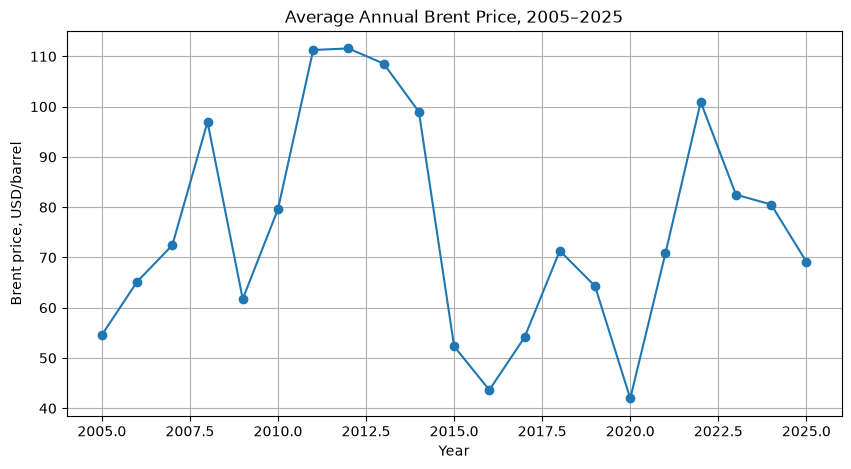

In [13]:
# Brent over time

plt.figure(figsize=(10, 5))

plt.plot(
    cop['observation_date'].dt.year,
    cop['brent_price_mean'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Brent price, USD/barrel')
plt.title('Average Annual Brent Price, 2005–2025')

plt.grid(True)
plt.show()

===================================================================
# Hypothesis Testing                                                 
===================================================================

Hypothesis
1) Higher average annual Saudi oil production (SAUNGDPMOMBD) is associated with lower average annual Brent prices;
2) Higher average annual UAE oil production (ARENGDPMOMBD) is associated with lower average annual Brent prices;
3) Higher global oil demand (World_Demand) is associated with higher average annual Brent prices;
4) A stronger nominal dollar index is associated with lower average annual Brent prices;
5) Global oil demand has a stronger association with Brent prices than oil production in Saudi Arabia and the UAE;
6) The association between Saudi oil production and Brent prices is stronger then that between UAE oil production and Brent prices.

In [14]:
#20.1 Now we compare Saudi oil production (SAUNGDPMOMBD) with lower average annual Brent prices and we use Pearson's correlation coefficient

Pearsons_correlation_Saudi = cop['SAUNGDPMOMBD'].corr(cop['brent_price_mean'], method='pearson')

print(Pearsons_correlation_Saudi)


-0.00045613518222863505


In [15]:
#20.2 Now we're counting other values for hypothesis
Pearsons_correlation_UAE = cop['ARENGDPMOMBD'].corr(cop['brent_price_mean'], method='pearson')
Pearsons_correlation_WD = cop['World_Demand'].corr(cop['brent_price_mean'], method='pearson')
Pearsons_correlation_DXY = cop['TWEXBGSANL'].corr(cop['brent_price_mean'], method='pearson')

print(
Pearsons_correlation_UAE,
Pearsons_correlation_WD,
Pearsons_correlation_DXY
)

-0.07554262693026581 -0.08987357522657262 -0.43782015292532295


In [16]:
Pearsons_correlation = {
    'Variable': ['SAUNGDPMOMBD', 'ARENGDPMOMBD', 'World_Demand', 'TWEXBGSANL'],
    'r': ['-0.0005', '-0.08', '-0.09', '-0.4'],
    'Meaning': ['Practically no connection', 'Weak connection', 'Very weak connection and unexpected sign', 'Medium connection, expected sign']
}
Pearsons_correlation_Table = pd.DataFrame(Pearsons_correlation)

print(Pearsons_correlation_Table)

       Variable        r                                   Meaning
0  SAUNGDPMOMBD  -0.0005                 Practically no connection
1  ARENGDPMOMBD    -0.08                           Weak connection
2  World_Demand    -0.09  Very weak connection and unexpected sign
3    TWEXBGSANL     -0.4          Medium connection, expected sign


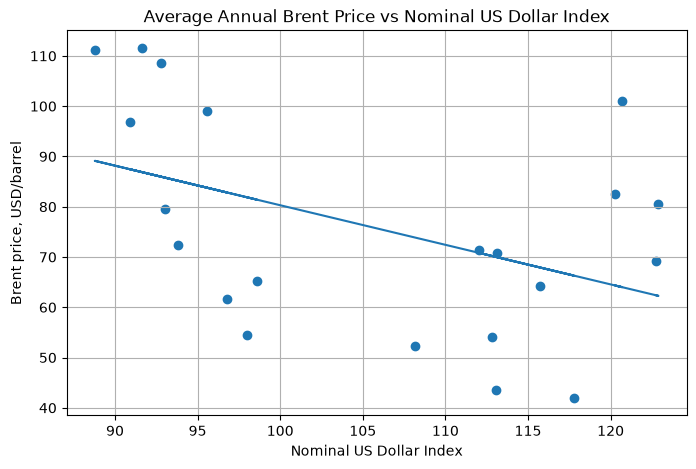

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    cop['TWEXBGSANL'],
    cop['brent_price_mean']
)

plt.xlabel('Nominal US Dollar Index')
plt.ylabel('Brent price, USD/barrel')
plt.title('Average Annual Brent Price vs Nominal US Dollar Index')

z = np.polyfit(cop['TWEXBGSANL'], cop['brent_price_mean'], 1)
p = np.poly1d(z)

plt.plot(cop['TWEXBGSANL'], p(cop['TWEXBGSANL']))

plt.grid(True)
plt.show()

***H1*** - The Pearson linear correlation coefficient is **close to zero** (r= -0.0005), which indicates the absence of a linear relationship between the variables.

***H2*** - **The relationship is very weak** (r= -0.08), indicating an extremely weak linear relationship between the variables under study. The direction of the relationship is formally negative, but its strength is negligibly small.

***H3*** - As a result of statistical processing of the empirical data, a correlation coefficient of (r= -0.09) was obtained. The obtained value is **close to zero**, which indicates an extremely weak linear relationship between the analyzed characteristics. However, the direction of the relationship turned out to be **negative**, which, in the context of the proposed theoretical assumptions, is an unexpected result and requires further analysis.
The reasons for this relationship are determined not so much by physical demand as by financial futures markets, geopolitical risks, and OPEC’s actions.

***H4*** - The correlation coefficient of Nominal DXY (r= -0.4). The obtained value indicates of a **moderate negative linear relationship**. It means that an increase in the values of one variable is systematically accompanied by decrease in the values of another.

In [18]:
#Pair linear regression
X = cop[['SAUNGDPMOMBD']]
Y = cop['brent_price_mean']

model = LinearRegression()
model.fit(X, Y)

a = model.intercept_
b = model.coef_[0]

print('a =', a)
print('b =', b)
print('R^2 =', model.score(X, Y))

a = 75.97656047764994
b = -1.536708781216492e-08
R^2 = 2.0805930422973518e-07


In [19]:
X = cop[['ARENGDPMOMBD']]
Y = cop['brent_price_mean']

model = LinearRegression()
model.fit(X, Y)

a = model.intercept_
b = model.coef_[0]

print('a =', a)
print('b =', b)
print('R^2 =', model.score(X, Y))

a = 92.99224066813659
b = -6.217104071069001e-06
R^2 = 0.005706688483525402


In [20]:
X = cop[['World_Demand']]
Y = cop['brent_price_mean']

model = LinearRegression()
model.fit(X, Y)

a = model.intercept_
b = model.coef_[0]

print('a =', a)
print('b =', b)
print('R^2 =', model.score(X, Y))

a = 101.97340984986145
b = -2.8077265097443414e-07
R^2 = 0.008077259524006064


In [21]:
X = cop[['TWEXBGSANL']]
Y = cop['brent_price_mean']

model = LinearRegression()
model.fit(X, Y)

a = model.intercept_
b = model.coef_[0]

print('a =', a)
print('b =', b)
print('R^2 =', model.score(X, Y))

a = 159.01977502174753
b = -0.7872428977925268
R^2 = 0.19168648630755292


Among the four factors considered, only the dollar index demonstrates a meaningful pairwise relationship with the Brent price (R^2=0.192), which is consistent with hypothesis H4. The production indicators for Saudi Arabia, the UAE, and global demand explain less than 1% of the price variation each individually, which does not confirm hypotheses H1, H2, H3 in their simple linear form. This may reflect the fact that the Brent price is determined by a combination of factors that cannot be reduced to a linear relationship with a single variable, or that the effect of each individual factor is manifested only in interaction with the others (see the results of multiple regression).

In [22]:
X = cop[
    [
        'World_Demand',
        'SAUNGDPMOMBD',
        'ARENGDPMOMBD',
        'TWEXBGSANL'
    ]
]

Y = cop['brent_price_mean']

X_ols = sm.add_constant(X)

ols_model = sm.OLS(Y, X_ols).fit()

print(ols_model.summary())



                            OLS Regression Results                            
Dep. Variable:       brent_price_mean   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     5.200
Date:                Fri, 04 Sep 2026   Prob (F-statistic):            0.00705
Time:                        21:15:22   Log-Likelihood:                -85.257
No. Observations:                  21   AIC:                             180.5
Df Residuals:                      16   BIC:                             185.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5272     83.441     -0.150   

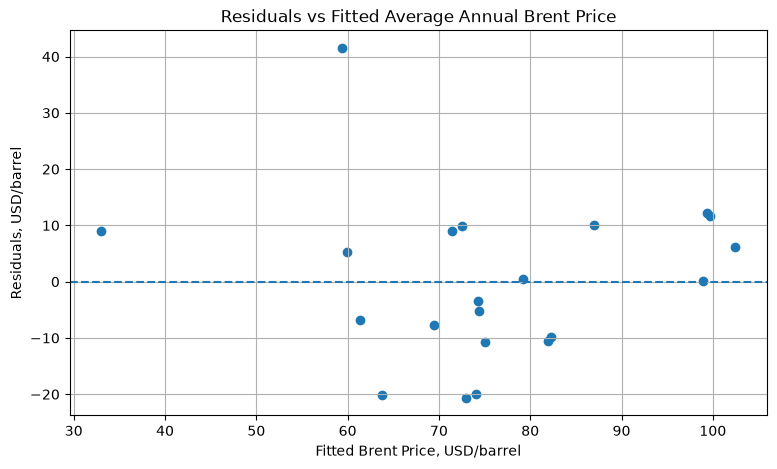

In [23]:
fitted = ols_model.fittedvalues
residuals = ols_model.resid


# Residuals vs Fitted Values
plt.figure(figsize=(9, 5))

plt.scatter(fitted, residuals)

plt.axhline(0, linestyle='--')

plt.xlabel('Fitted Brent Price, USD/barrel')
plt.ylabel('Residuals, USD/barrel')
plt.title('Residuals vs Fitted Average Annual Brent Price')

plt.grid(True)
plt.show()


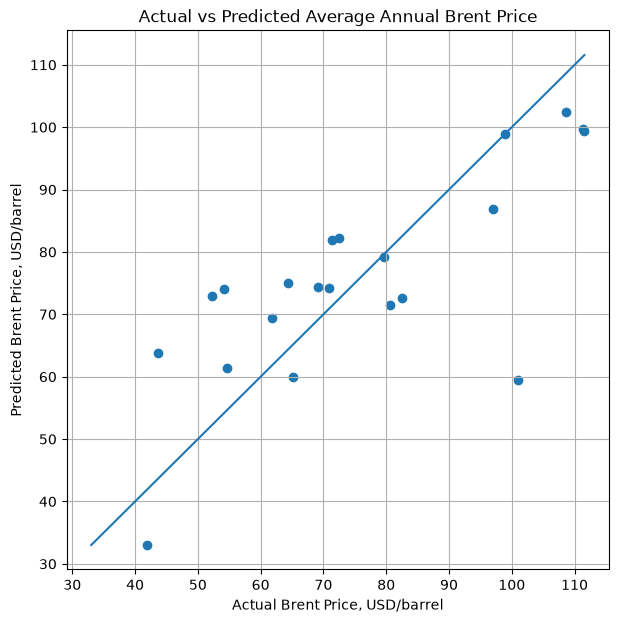

In [24]:
predicted = ols_model.predict(X_ols)

plt.figure(figsize=(7, 7))

plt.scatter(Y, predicted)

plt.xlabel('Actual Brent Price, USD/barrel')
plt.ylabel('Predicted Brent Price, USD/barrel')
plt.title('Actual vs Predicted Average Annual Brent Price')

min_value = min(Y.min(), predicted.min())
max_value = max(Y.max(), predicted.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.grid(True)
plt.show()

The multiple linear regression results indicate that the model has a moderate explanatory power, with an R^2 of 0.565 and an adjusted R^2 of 0.456. Thus, the selected four factors explain approximately 56.5% of the variation in the average annual Brent price within the analyzed sample.

The F-test shows that the regression model is statistically significant as a whole (F = 5.20, p = 0.007). Among the individual predictors, global oil demand and the nominal US dollar index demonstrate statistically significant relationships with Brent prices. World oil demand has a positive coefficient (p = 0.016), indicating that higher global oil demand is associated with higher average annual Brent prices, which supports H3. The nominal US dollar index has a negative coefficient (p < 0.001), indicating that a stronger dollar is associated with lower Brent prices, which supports H4.

The coefficients for Saudi Arabian and UAE oil production are not statistically significant (p = 0.874 and p = 0.723, respectively). Therefore, H1 and H2 are not supported by the multiple regression results. Although the UAE production coefficient has the expected negative sign, the relationship is not statistically significant, while the Saudi production coefficient has a positive rather than the hypothesized negative sign.

Overall, the multiple regression provides evidence that global oil demand and the nominal US dollar index have statistically significant associations with Brent prices in the analyzed sample, whereas the individual effects of Saudi Arabian and UAE oil production are not statistically significant.

In [25]:
#VIF (Variance Inflation Factor)

vif = pd.DataFrame()

vif['Variable'] = X.columns
vif['VIF'] = np.nan

for i in range(X.shape[1]):

    y_vif = X.iloc[:, i]

    X_vif = X.drop(X.columns[i], axis=1)

    model_vif = LinearRegression()

    model_vif.fit(X_vif, y_vif)

    R2 = model_vif.score(X_vif, y_vif)

    vif.loc[i, 'VIF'] = 1 / (1 - R2)

print(vif)

       Variable  VIF
0  World_Demand   10
1  SAUNGDPMOMBD    4
2  ARENGDPMOMBD   12
3    TWEXBGSANL    4


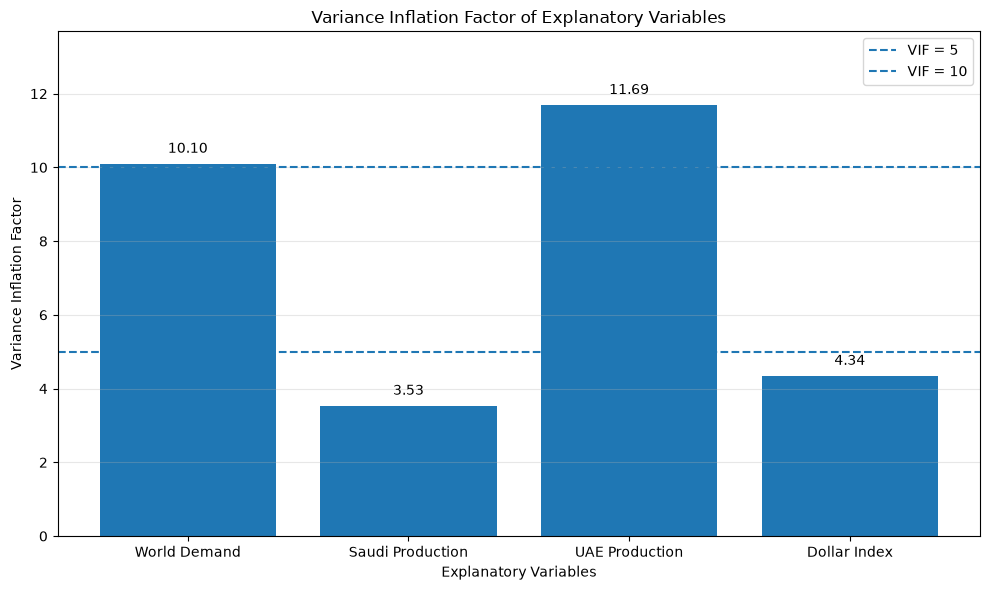

In [26]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    ['World Demand', 'Saudi Production', 'UAE Production', 'Dollar Index'],
    vif['VIF']
)

for bar, value in zip(bars, vif['VIF']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.3,
        f'{value:.2f}',
        ha='center'
    )

plt.axhline(
    5,
    linestyle='--',
    label='VIF = 5'
)

plt.axhline(
    10,
    linestyle='--',
    label='VIF = 10'
)
plt.ylabel('Variance Inflation Factor')
plt.xlabel('Explanatory Variables')
plt.title('Variance Inflation Factor of Explanatory Variables')
plt.xticks(rotation=0)
plt.ylim(0, max(vif['VIF']) + 2)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The four selected factors together provide a statistically significant regression model and explain a substantial portion of the variation in the average annual Brent price, with an R^2 of 0.565. Among the individual factors, global oil demand and the nominal dollar index have statistically significant coefficients, while the Saudi Arabian and UAE oil production coefficients are statistically insignificant.

The VIF analysis indicates the presence of multicollinearity among some of the independent variables. In particular, World_Demand has a VIF of approximately 10, while ARENGDPMOMBD has a VIF of approximately 12, indicating a high degree of multicollinearity. Therefore, the estimated coefficients for these variables should be interpreted with caution, as their estimates may be affected by the strong linear relationship between the predictors.

The analysis shows that the relationship between the selected factors and the average annual Brent price differs substantially depending on whether the factors are considered individually or simultaneously.

The pairwise analysis showed that the nominal US dollar index had the strongest individual relationship with Brent prices, with a Pearson correlation coefficient of approximately -0.44 and an R^2 of 0.192. In contrast, the relationships between Brent prices and Saudi Arabian oil production, UAE oil production, and global oil demand were very weak, with each individual regression explaining less than 1% of the variation in Brent prices.
The multiple OLS regression provides a different picture. The model is statistically significant as a whole (F = 5.20, p = 0.00705) and explains approximately 56.5% of the variation in average annual Brent prices (R^2 = 0.565; adjusted R^2 = 0.456). Global oil demand has a statistically significant positive coefficient (p = 0.016), while the nominal US dollar index has a statistically significant negative coefficient (p < 0.001). These results support H3 and H4 within the estimated model. In contrast, the coefficients for Saudi Arabian and UAE oil production are statistically insignificant (p = 0.874 and p = 0.723), so H1 and H2 are not supported.

The VIF analysis indicates multicollinearity among several independent variables. In particular, World_Demand has a VIF of approximately 10 and ARENGDPMOMBD has a VIF of approximately 12, while Saudi Arabian oil production and the dollar index have lower VIF values of approximately 4. Therefore, the estimated coefficients, especially for global demand and UAE production, should be interpreted with caution.

Overall, the results suggest that global oil demand and the strength of the US dollar are the most statistically important factors among those included in the model, whereas the individual contribution of Saudi Arabian and UAE oil production is not statistically significant in the analyzed sample. H5 is generally consistent with the results, as global demand demonstrates a stronger statistical association with Brent than either production variable, although this comparison should be interpreted cautiously because the predictors are measured on different scales and multicollinearity is present. H6 is not supported, as the Saudi Arabian production variable does not demonstrate a stronger relationship with Brent than UAE production.

Thus, the analysis provides evidence that Brent prices are associated with a combination of global demand conditions and the strength of the US dollar, while the role of Saudi and UAE production is less clear within the linear annual model. The results should be interpreted as statistical associations rather than direct causal effects, particularly given the relatively small sample of 21 annual observations and the detected multicollinearity.